In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/ConcreteData_cleaned.csv")

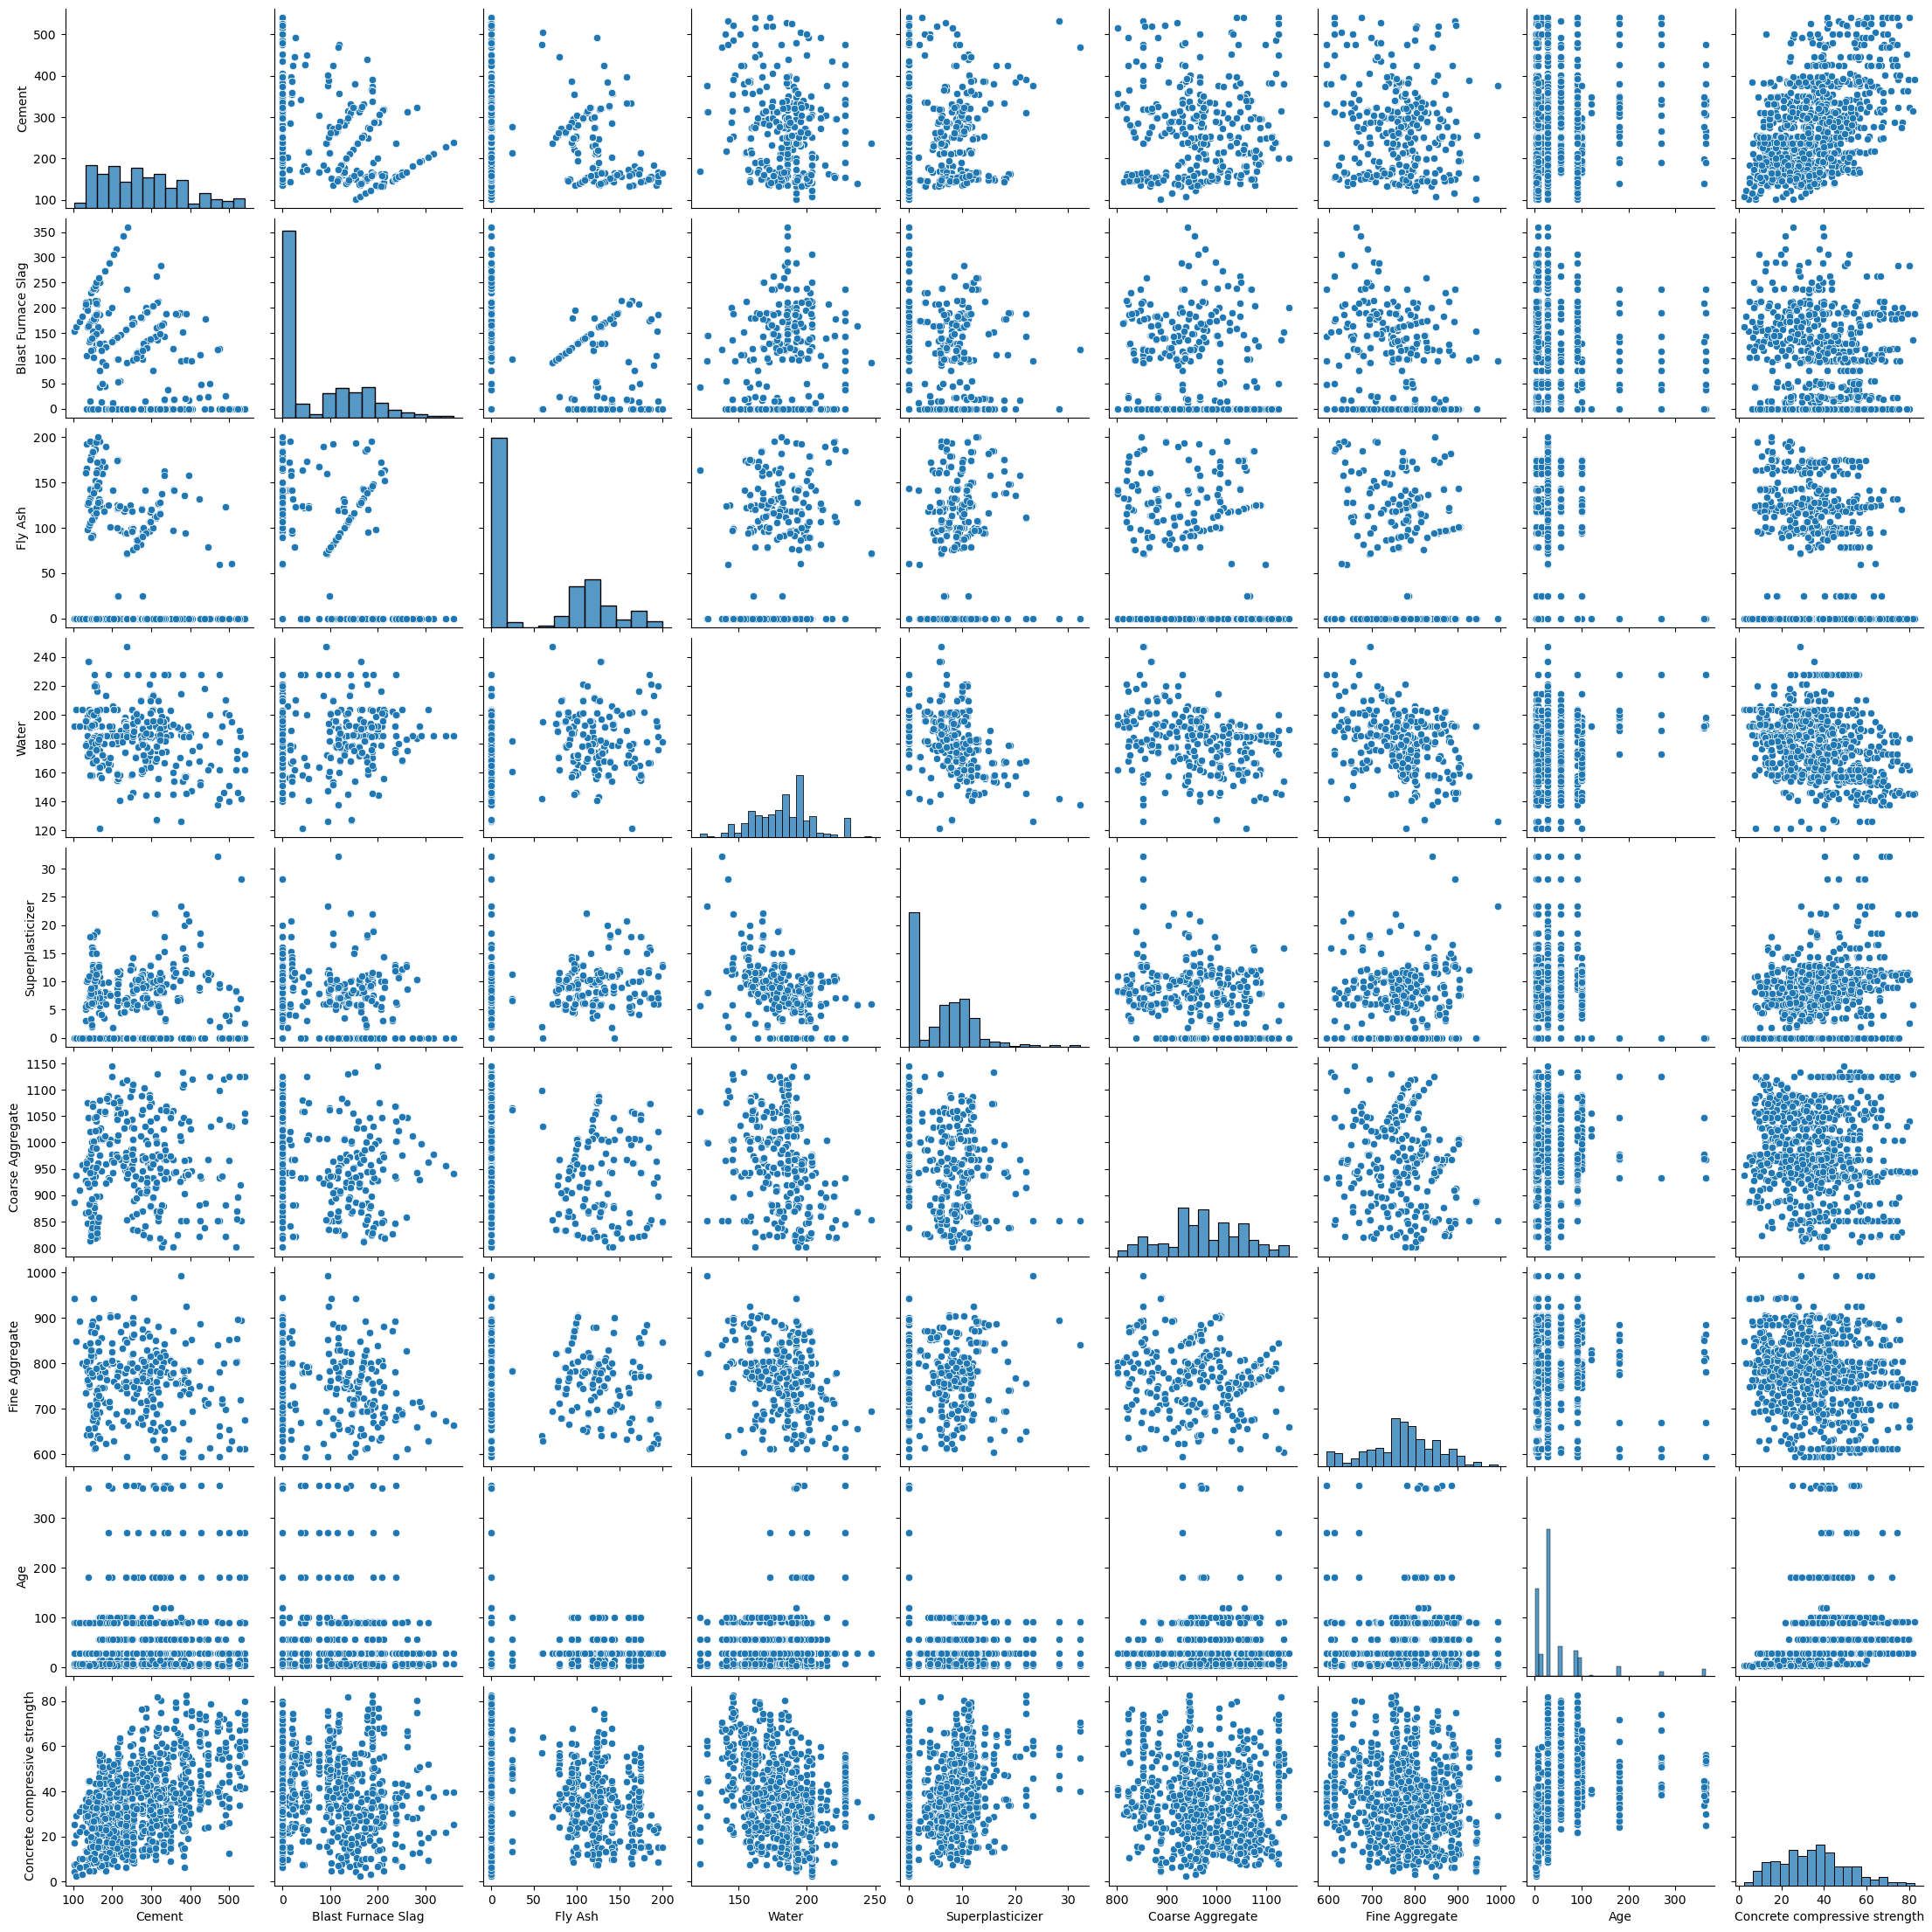

In [3]:
sns.pairplot(df)
plt.show()

The clearest correlation we see with the target, compressive strength, is the amount of cement. The next most important is perhaps age. There may be some minor correlation between amounts of cement, slag, and fly ash. These three components are collectively considered binders.

We may want to 'normalize' the data row-wise such that for each mixture we have the proportion of the total mixture for each component. This puts the values on the same scale for further analysis. Age and Compressive strength can be scaled by dividing by the maximum value in the column

In [4]:
df_normalized = pd.DataFrame()
df_normalized['Cement'] = df['Cement']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Blast Furnace Slag'] = df['Blast Furnace Slag']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Fly Ash'] = df['Fly Ash']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Water'] = df['Water']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Superplasticizer'] = df['Superplasticizer']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Coarse Aggregate'] = df['Coarse Aggregate']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Fine Aggregate'] = df['Fine Aggregate']/(df['Cement']+df['Blast Furnace Slag']+df['Fly Ash']+df['Water']+df['Superplasticizer']+df['Coarse Aggregate']+df['Fine Aggregate'])
df_normalized['Age'] = df['Age']/df['Age'].max()
df_normalized['Concrete compressive strength'] = df['Concrete compressive strength']/df['Concrete compressive strength'].max()

Let's look at some ECDFs

In [5]:
def ecdf(data):
    """Compute ECDF for a one-dimensional array of measurements."""
    # Number of data points: n
    n = len(data)

    # x-data for the ECDF: x
    x = np.sort(data)

    # y-data for the ECDF: y
    y = np.arange(1, n+1) / n

    return x, y

In [6]:
x_cement, y_cement = ecdf(df_normalized['Cement'])
x_slag, y_slag = ecdf(df_normalized['Blast Furnace Slag'])
x_ash, y_ash = ecdf(df_normalized['Fly Ash'])
x_water, y_water = ecdf(df_normalized['Water'])
x_sp, y_sp = ecdf(df_normalized['Superplasticizer'])
x_ca, y_ca = ecdf(df_normalized['Coarse Aggregate'])
x_fa, y_fa = ecdf(df_normalized['Fine Aggregate'])

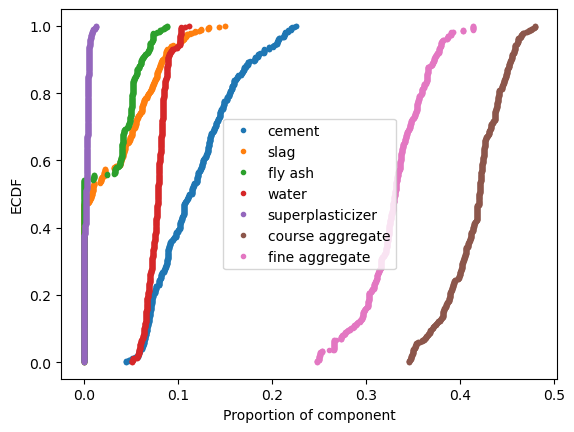

In [7]:
plt.plot(x_cement,y_cement,marker='.',linestyle='none',label='cement')
plt.plot(x_slag,y_slag,marker='.',linestyle='none',label='slag')
plt.plot(x_ash,y_ash,marker='.',linestyle='none',label='fly ash')
plt.plot(x_water,y_water,marker='.',linestyle='none',label='water')
plt.plot(x_sp,y_sp,marker='.',linestyle='none',label='superplasticizer')
plt.plot(x_ca,y_ca,marker='.',linestyle='none',label='course aggregate')
plt.plot(x_fa,y_fa,marker='.',linestyle='none',label='fine aggregate')
plt.legend()
plt.xlabel("Proportion of component")
plt.ylabel("ECDF")
plt.show()

While there does not seem to be a correlation between fine and course aggregates with compressive strength, these components make up the bulk of the mixtures.

# Feature Engineering

Categorical features reporting whether or not the mixture contains slag, fly ash, and superplasticizer

In [8]:
#For ingredients that are commonly 0, create feature that is 1 if the mixture contains any and 0 if not
df['contains_BlastFurnaceSlag'] = (df['Blast Furnace Slag'] != 0)*1
df['contains_FlyAsh'] = (df['Fly Ash'] != 0)*1
df['contains_Superplasticizer'] = (df['Superplasticizer'] != 0)*1

From some domain knowledge research, the following quantities may be relevant:
- water:cement ratio
- water:binder ratio (where binder is the total cement, fly ash, and slag)
- superplasticizer:binder ratio
- fly ash:binder ratio
- slag:binder ratio
- slag+fly ash:binder ratio

In [9]:
df['w_c_ratio'] = df['Water']/df['Cement']
df['w_binder_ratio'] = df['Water']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
df['sp_binder_ratio'] = df['Superplasticizer']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
df['fa_binder_ratio'] = df['Fly Ash']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
df['bfs_binder_ratio'] = df['Blast Furnace Slag']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
df['bfs_fa_binder_ratio'] = (df['Blast Furnace Slag']+df['Fly Ash'])/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])

Plot the relationships of these new features to compressive strength

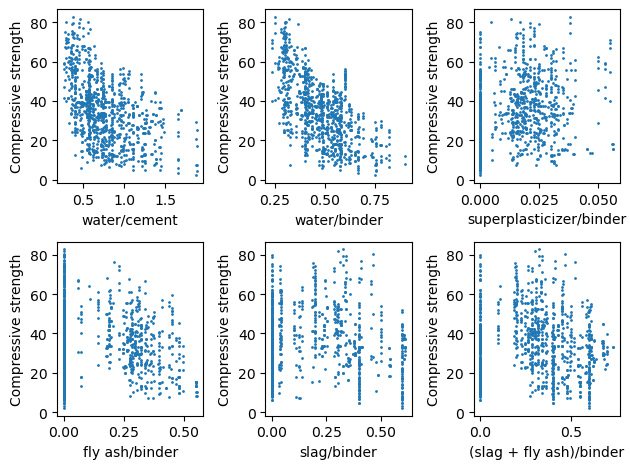

In [10]:
fig, ax = plt.subplots(2,3)
ax[0,0].scatter(df['w_c_ratio'],df['Concrete compressive strength'],s=1)
ax[0,0].set_xlabel('water/cement')
ax[0,0].set_ylabel('Compressive strength')

ax[0,1].scatter(df['w_binder_ratio'],df['Concrete compressive strength'],s=1)
ax[0,1].set_xlabel('water/binder')
ax[0,1].set_ylabel('Compressive strength')

ax[0,2].scatter(df['sp_binder_ratio'],df['Concrete compressive strength'],s=1)
ax[0,2].set_xlabel('superplasticizer/binder')
ax[0,2].set_ylabel('Compressive strength')

ax[1,0].scatter(df['fa_binder_ratio'],df['Concrete compressive strength'],s=1)
ax[1,0].set_xlabel('fly ash/binder')
ax[1,0].set_ylabel('Compressive strength')

ax[1,1].scatter(df['bfs_binder_ratio'],df['Concrete compressive strength'],s=1)
ax[1,1].set_xlabel('slag/binder')
ax[1,1].set_ylabel('Compressive strength')

ax[1,2].scatter(df['bfs_fa_binder_ratio'],df['Concrete compressive strength'],s=1)
ax[1,2].set_xlabel('(slag + fly ash)/binder')
ax[1,2].set_ylabel('Compressive strength')

plt.tight_layout()
plt.show()

There is a substantial negative correlation with the target for water:cement ratio and water:binder ratio. Let's look deeper, computing correlation coefficients and p values via a permutation test

In [25]:
def permutation_test(df,feature_column,target_column='Concrete compressive strength',size=10000):
    obs_corr = np.corrcoef(df[feature_column],df[target_column])[0,1]
    perm_corr = np.empty(size)
    for i in range(size):
        feature_perm = np.random.permutation(df[feature_column])
        corr_perm = np.corrcoef(feature_perm,df[target_column])[0,1]
        perm_corr[i] = np.abs(corr_perm)
    p = np.sum(perm_corr >= np.abs(obs_corr))/len(perm_corr)
    
    return obs_corr, p

In [26]:
corrs_ps = []
for col in df.columns:
    obs_corr, p = permutation_test(df,col)
    corrs_ps.append((col,obs_corr,p))
corrs_ps.sort(key=lambda x: np.abs(x[1]), reverse=True)

for feature_column, obs_corr, p in corrs_ps:
    print("Observed correlation coefficient for "+ feature_column + f" is {obs_corr:.2f} with p value = " + str(p))

Observed correlation coefficient for Concrete compressive strength is 1.00 with p value = 0.0
Observed correlation coefficient for w_binder_ratio is -0.61 with p value = 0.0
Observed correlation coefficient for w_c_ratio is -0.49 with p value = 0.0
Observed correlation coefficient for Cement is 0.49 with p value = 0.0
Observed correlation coefficient for Superplasticizer is 0.34 with p value = 0.0
Observed correlation coefficient for Age is 0.34 with p value = 0.0
Observed correlation coefficient for contains_Superplasticizer is 0.27 with p value = 0.0
Observed correlation coefficient for Water is -0.27 with p value = 0.0
Observed correlation coefficient for sp_binder_ratio is 0.22 with p value = 0.0
Observed correlation coefficient for contains_BlastFurnaceSlag is 0.20 with p value = 0.0
Observed correlation coefficient for Fine Aggregate is -0.19 with p value = 0.0
Observed correlation coefficient for fa_binder_ratio is -0.14 with p value = 0.0
Observed correlation coefficient for Co

Let's also look at the heatmap of correlation coefficients

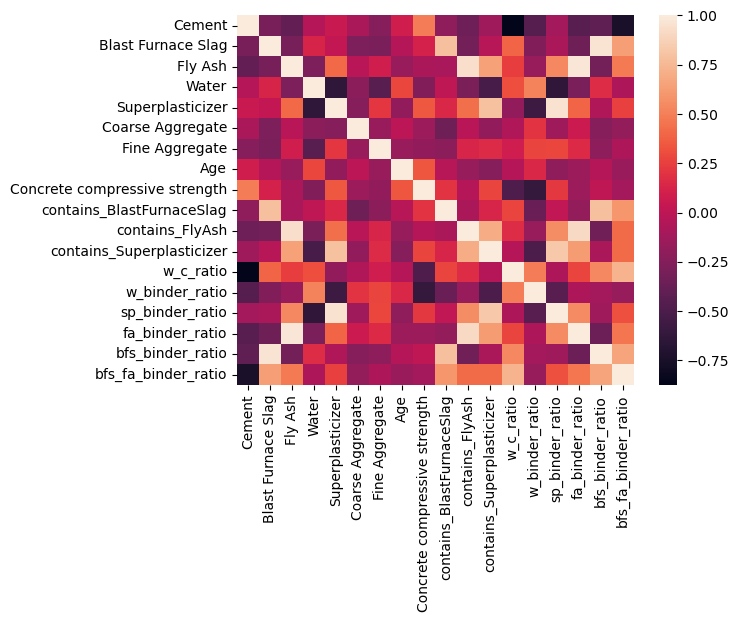

In [24]:
sns.heatmap(df.corr())
plt.show()

As we expected there is significant correlation with the target for cement, and age. There is also significant correlation with superplasticizer. Of the new engineered features, the most interesting is the strong correlation of water:binder ratio with compressive strength. This reveals a strong relationship in the data that wasnt clear from looking at the initial set of one-to-one correlation plots.

In [37]:
feature, corr, p = zip(*corrs_ps)
feature = list(feature)
corr = list(corr)

C:\Users\Adam\AppData\Local\Temp\ipykernel_27892\3347166658.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Water:binder\n ratio","Water:cement\n ratio","Cement","Superplasticizer"])


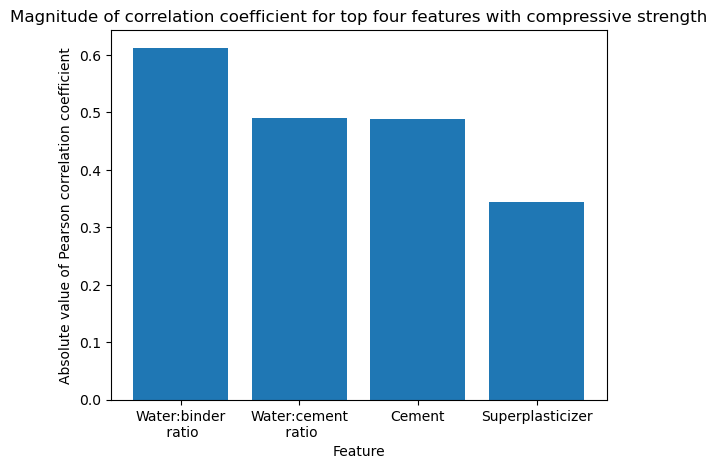

In [53]:
corrs_to_plot = corr[1:5]
feats_to_plot = feature[1:5]
fig, ax = plt.subplots()
plt.bar(feats_to_plot,np.abs(corrs_to_plot))
plt.title("Magnitude of correlation coefficient for top four features with compressive strength")
plt.xlabel("Feature")
plt.ylabel("Absolute value of Pearson correlation coefficient")
ax.set_xticklabels(["Water:binder\n ratio","Water:cement\n ratio","Cement","Superplasticizer"])
plt.show()

Let's look at some more plots combining more variables

In [149]:
#Utility function for making more complex scatter plots
def scatter_color_size(x,y,c,s,categories,xlabel,ylabel='Compressive strength (MPa)'):
    """Utility for plotting a scatterplot with colored categories and size component (Age)"""
    fig, ax = plt.subplots()
    scatter = ax.scatter(x,y,c=c,s=s,alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    handles, labels = scatter.legend_elements()
    legend_colors = ax.legend(handles, [categories[i] for i,l in enumerate(labels)])
    ax.add_artist(legend_colors)
    legend_sizes = ax.legend(*scatter.legend_elements(prop="sizes", num=[10,150,300]), loc="lower right", title="Age")
    plt.show()

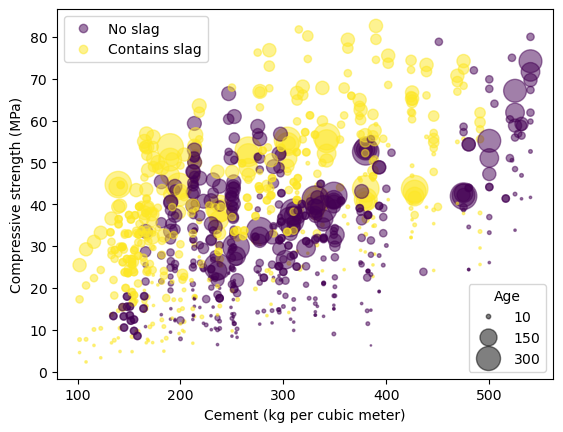

In [106]:
scatter_color_size(df['Cement'], df['Concrete compressive strength'], c=df['contains_BlastFurnaceSlag'], s=df['Age'],
                   categories=['No slag','Contains slag'], xlabel='Cement (kg per cubic meter)')

The trend with increasing cement can be seen in combination with the effect of including slag in the mixture. It seems that in general, including slag improves compressive strength. It can also be seen that for a given amount of cement there tend to be vertical clusters of data points that are generally higher (in strength) as they are aged longer.

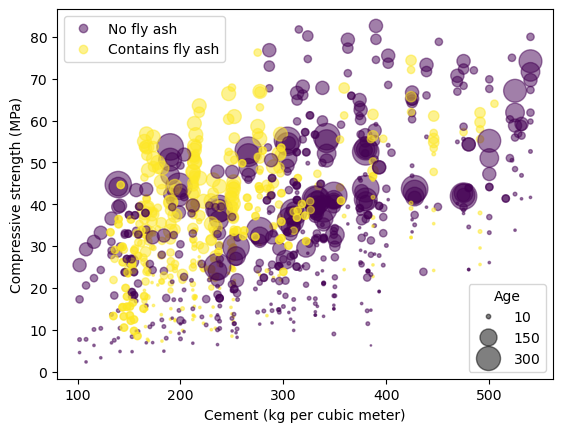

In [107]:
scatter_color_size(df['Cement'], df['Concrete compressive strength'], c=df['contains_FlyAsh'], s=df['Age'],
                   categories=['No fly ash','Contains fly ash'], xlabel='Cement (kg per cubic meter)')

Similar trends can be seen here but there doesn't seem to be a clear benefit from including fly ash

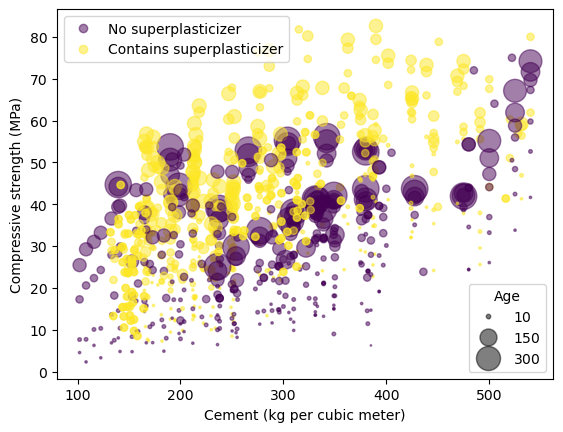

In [108]:
scatter_color_size(df['Cement'], df['Concrete compressive strength'], c=df['contains_Superplasticizer'], s=df['Age'],
                   categories=['No superplasticizer','Contains superplasticizer'], xlabel='Cement (kg per cubic meter)')

Seems to be some benefit from including superplasticizer

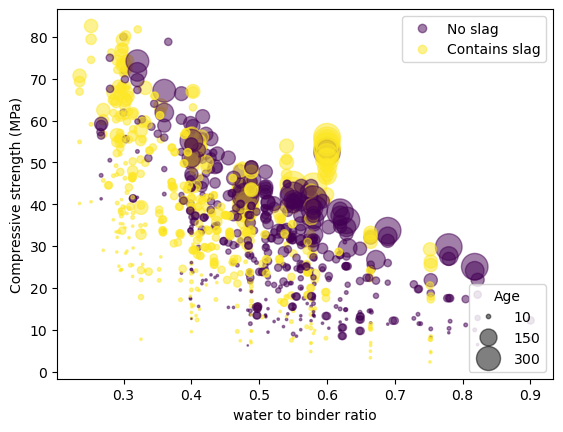

In [116]:
scatter_color_size(df['w_binder_ratio'], df['Concrete compressive strength'], c=df['contains_BlastFurnaceSlag'], s=df['Age'],
                   categories=['No slag','Contains slag'], xlabel='water to binder ratio')

The water to binder ratio seems quite important. Here, it is less clear that slag improves strength.

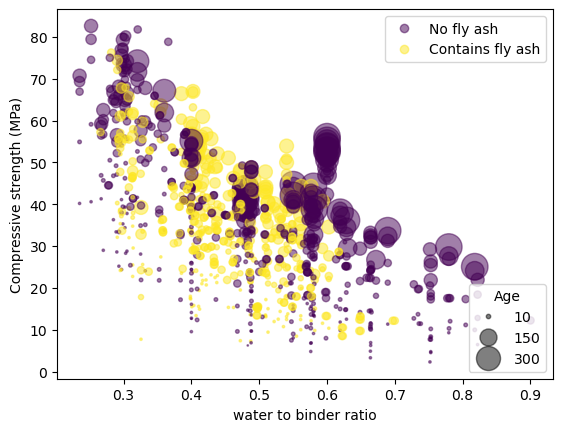

In [115]:
scatter_color_size(df['w_binder_ratio'], df['Concrete compressive strength'], c=df['contains_FlyAsh'], s=df['Age'],
                   categories=['No fly ash','Contains fly ash'], xlabel='water to binder ratio')

Perhaps benefit is gained from including no fly ash and aging for many days

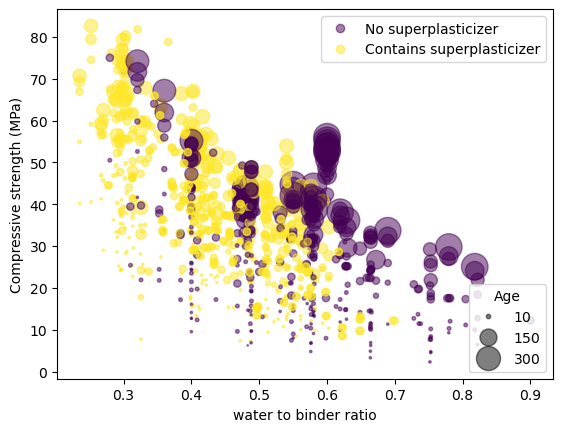

In [117]:
scatter_color_size(df['w_binder_ratio'], df['Concrete compressive strength'], c=df['contains_Superplasticizer'], s=df['Age'],
                   categories=['No superplasticizer','Contains superplasticizer'], xlabel='water to binder ratio')

The majority of high strength mixtures contain superplasticizer